In [62]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from PIL import Image

In [63]:
img = cv.imread("swiss.jpg",1)
color_img = img.copy()

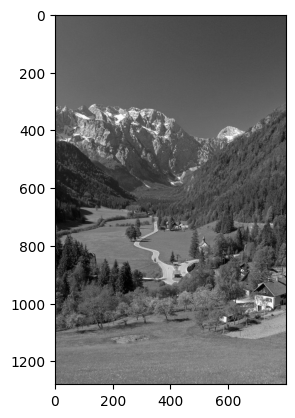

In [64]:
img = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
plt.imshow(img, cmap='gray')
cv.imwrite("swiss_gray.jpg",img)
plt.show()

True

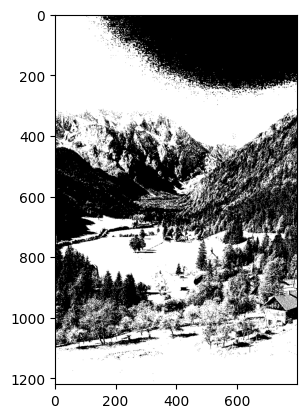

In [83]:
baw = img > 87 
plt.imshow(baw, cmap='gray')
cv.imwrite("swiss_black_and_white.jpg",baw.astype(int)*255)


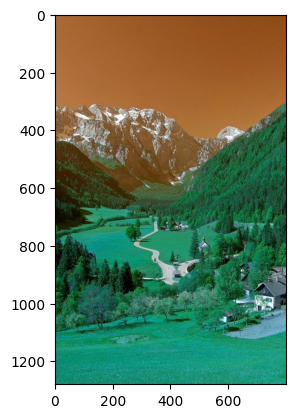

In [66]:
plt.imshow(color_img)

In [67]:
color_img.shape

(1280, 800, 3)

In [68]:
img.shape

(1280, 800)

In [69]:
img = img[0:1220,:]
img.shape

(1220, 800)

In [70]:
np.sum(img[0:2,0:2])

385

In [71]:
bayer_0 = np.array([[1,1],
                    [1,1]])

bayer_1 = np.array([[0,1],
                    [1,1]])

bayer_2 = np.array([[0,1],
                    [1,0]])

bayer_3 = np.array([[0,0],
                    [1,0]])

bayer_4 = np.array([[0,0],
                    [0,0]])

bayer_filters = [bayer_0,bayer_1,bayer_2,bayer_3,bayer_4]
bayer_filters = bayer_filters[::-1]

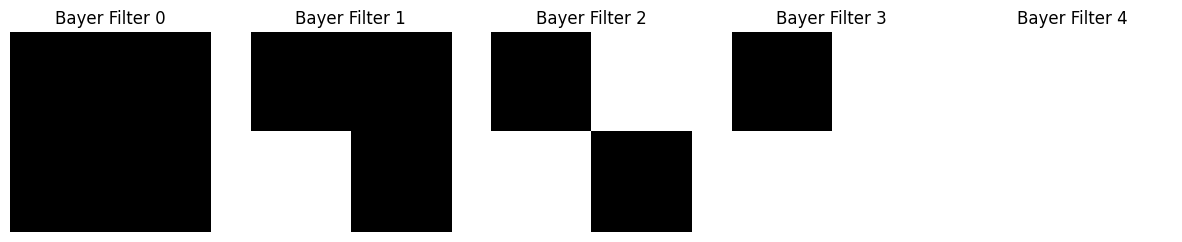

In [72]:
# View Bayer filters
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axs[i].imshow(bayer_filters[i]*255, cmap='gray', vmin=0, vmax=255)
    axs[i].set_title(f'Bayer Filter {i}')
    axs[i].axis('off')
plt.show()


In [73]:
def get_bayer(mat:np.array):
    avg = np.sum(mat)/4
    num = int((avg/(255+1)) * 5)

    return bayer_filters[num]


In [74]:
new = img.copy()

for i in range(int(img.shape[0]/2)):
    for j in range(int(img.shape[1]/2)):
        x=2*i
        y = 2*j
        new[x:x+2,y:y+2] = get_bayer(img[x:x+2,y:y+2])
        
        

In [75]:
new

array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 1, ..., 0, 1, 0],
       [0, 1, 0, ..., 1, 0, 1],
       [1, 0, 1, ..., 0, 1, 0]], dtype=uint8)

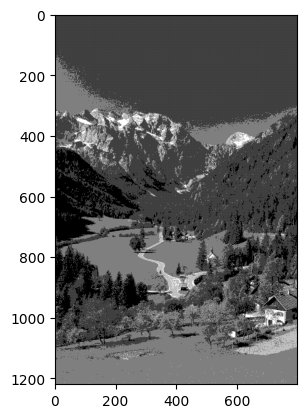

In [76]:
plt.imshow(new, cmap='gray')
plt.show()

In [77]:
cv.imwrite("swiss_bayer_2x2.jpg",new*255)

True

In [78]:
color_img = color_img[0:1220,:]

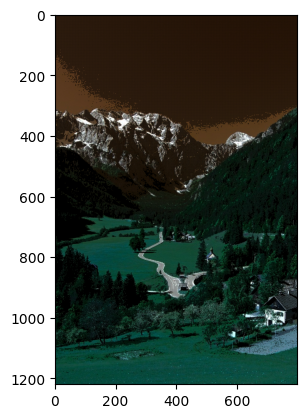

In [79]:
new_bayer = new[:,:,np.newaxis] * color_img
plt.imshow(new_bayer)
plt.show()

In [80]:
cv.imwrite("swiss_bayer_color.jpg",new_bayer)

True